# CSD361 - Lab Assignment 1: Data Preprocessing and Linear Regression

**Course**: CSD361 Introduction to Machine Learning  
**Topic**: Data Exploration, Normalization, Linear Regression, Gradient Descent Optimization, and Outlier Analysis  
**Dataset**: Chicago Taxi Trips Dataset (`Taxi_Trips_-_2024_20240408.csv`)  
**Environment**: Python 3.12 (NumPy, Pandas, Matplotlib, Seaborn, Scikit-Learn)  

---

## Objective
Develop a Linear Regression model to predict taxi trip fare and investigate how different normalization techniques (Original vs. Min-Max vs. Z-Score Standardization) affect:
1. Model training & parameter estimation
2. Closed-form OLS vs. Iterative Gradient Descent convergence
3. Loss landscape geometry & learning rate sensitivity
4. Robustness against extreme dataset outliers

---

In [1]:
# Import required libraries
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configure visualization aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 150

print(f"NumPy: {np.__version__} | Pandas: {pd.__version__}")


NumPy: 2.4.4 | Pandas: 3.0.3


---
# Part I: Dataset Exploration

### Tasks:
1. Determine the number of observations and attributes.
2. Classify attributes into Numerical, Categorical, Identifier, Timestamp, and Spatial.
3. Identify missing values in each attribute.
4. Identify duplicate records.
5. Calculate descriptive statistics for `trip_seconds`, `trip_miles`, `fare`, `tips`, `tolls`, `extras`.
6. Plot distributions of numerical variables.


In [2]:
# 1. Load Dataset and Determine Dimensions
DATA_PATH = 'Taxi_Trips_-_2024_20240408.csv'
df_raw = pd.read_csv(DATA_PATH)
n_obs, n_attrs = df_raw.shape

print(f"Total Observations (Rows): {n_obs:,}")
print(f"Total Attributes (Columns): {n_attrs}")


Total Observations (Rows): 865,247
Total Attributes (Columns): 23


In [3]:
# 2. Attribute Identification and Categorization
attr_categories = {
    "Numerical (Continuous/Discrete)": [
        "Trip Seconds", "Trip Miles", "Fare", "Tips", "Tolls", "Extras", "Trip Total",
        "Pickup Centroid Latitude", "Pickup Centroid Longitude",
        "Dropoff Centroid Latitude", "Dropoff Centroid Longitude"
    ],
    "Categorical (Nominal/Ordinal)": [
        "Payment Type", "Company", "Pickup Community Area", "Dropoff Community Area",
        "Pickup Census Tract", "Dropoff Census Tract"
    ],
    "Identifier (Unique Keys/Hashes)": ["Trip ID", "Taxi ID"],
    "Timestamp (Temporal Datetime)": ["Trip Start Timestamp", "Trip End Timestamp"],
    "Spatial/Geographic (WKT Format)": ["Pickup Centroid Location", "Dropoff Centroid  Location"]
}

for cat, cols in attr_categories.items():
    print(f"=== {cat} ({len(cols)}) ===")
    for c in cols:
        print(f"  • {c}")
    print()


=== Numerical (Continuous/Discrete) (11) ===
  • Trip Seconds
  • Trip Miles
  • Fare
  • Tips
  • Tolls
  • Extras
  • Trip Total
  • Pickup Centroid Latitude
  • Pickup Centroid Longitude
  • Dropoff Centroid Latitude
  • Dropoff Centroid Longitude

=== Categorical (Nominal/Ordinal) (6) ===
  • Payment Type
  • Company
  • Pickup Community Area
  • Dropoff Community Area
  • Pickup Census Tract
  • Dropoff Census Tract

=== Identifier (Unique Keys/Hashes) (2) ===
  • Trip ID
  • Taxi ID

=== Timestamp (Temporal Datetime) (2) ===
  • Trip Start Timestamp
  • Trip End Timestamp

=== Spatial/Geographic (WKT Format) (2) ===
  • Pickup Centroid Location
  • Dropoff Centroid  Location



In [4]:
# 3. Missing Value Analysis
missing_analysis = pd.DataFrame({
    'Attribute': df_raw.columns,
    'Data Type': df_raw.dtypes.astype(str).values,
    'Missing Count': df_raw.isnull().sum().values,
    'Missing Percentage (%)': (df_raw.isnull().sum().values / n_obs * 100).round(4)
}).sort_values(by='Missing Count', ascending=False).reset_index(drop=True)

print("Missing Value Breakdown:")
display(missing_analysis)


Missing Value Breakdown:


,Attribute,Data Type,Missing Count,Missing Percentage (%)
0,Dropoff Census Tract,float64,551393,63.7267
1,Pickup Census Tract,float64,537996,62.1783
2,Dropoff Community Area,float64,83853,9.6912
3,Dropoff Centroid Longitude,float64,79675,9.2084
4,Dropoff Centroid Location,str,79675,9.2084
5,Dropoff Centroid Latitude,float64,79675,9.2084
6,Pickup Community Area,float64,23195,2.6807
7,Pickup Centroid Location,str,22966,2.6543
8,Pickup Centroid Latitude,float64,22966,2.6543
9,Pickup Centroid Longitude,float64,22966,2.6543


In [5]:
# 4. Duplicate Records Check
dup_count = df_raw.duplicated().sum()
unique_trips = df_raw['Trip ID'].nunique()

print(f"Exact Duplicate Rows: {dup_count}")
print(f"Unique Trip IDs: {unique_trips:,} / {n_obs:,} (100.0% Unique)")


Exact Duplicate Rows: 0
Unique Trip IDs: 865,247 / 865,247 (100.0% Unique)


In [6]:
# 5. Descriptive Statistics for Target Numerical Attributes
target_cols = ['Trip Seconds', 'Trip Miles', 'Fare', 'Tips', 'Tolls', 'Extras']
stats = df_raw[target_cols].describe().T
stats['median'] = df_raw[target_cols].median()
stats['skewness'] = df_raw[target_cols].skew()
stats['kurtosis'] = df_raw[target_cols].kurtosis()

desc_table = stats[['count', 'mean', 'std', 'min', '25%', 'median', '75%', 'max', 'skewness', 'kurtosis']].copy()
desc_table.columns = ['Count', 'Mean', 'Std Dev', 'Min', '25% (Q1)', 'Median (50%)', '75% (Q3)', 'Max', 'Skewness', 'Kurtosis']
display(desc_table.round(4))


,Count,Mean,Std Dev,Min,25% (Q1),Median (50%),75% (Q3),Max,Skewness,Kurtosis
Trip Seconds,865078.0,1150.5320,1584.2435,0.0,459.00,900.00,1591.00,86340.00,24.5766,922.1414
Trip Miles,865241.0,6.5633,8.2795,0.0,0.91,3.07,11.71,3093.47,75.0750,24620.6192
Fare,863202.0,22.0574,25.1458,0.0,8.00,15.75,33.75,9999.75,159.3988,59168.8580
Tips,863202.0,2.7613,4.1330,0.0,0.00,0.00,4.00,200.00,3.0634,39.3330
Tolls,863202.0,0.0632,12.9552,0.0,0.00,0.00,0.00,4444.44,323.0475,106772.5404
Extras,863202.0,2.1493,19.3198,0.0,0.00,0.00,3.00,5051.10,198.0573,44803.9082


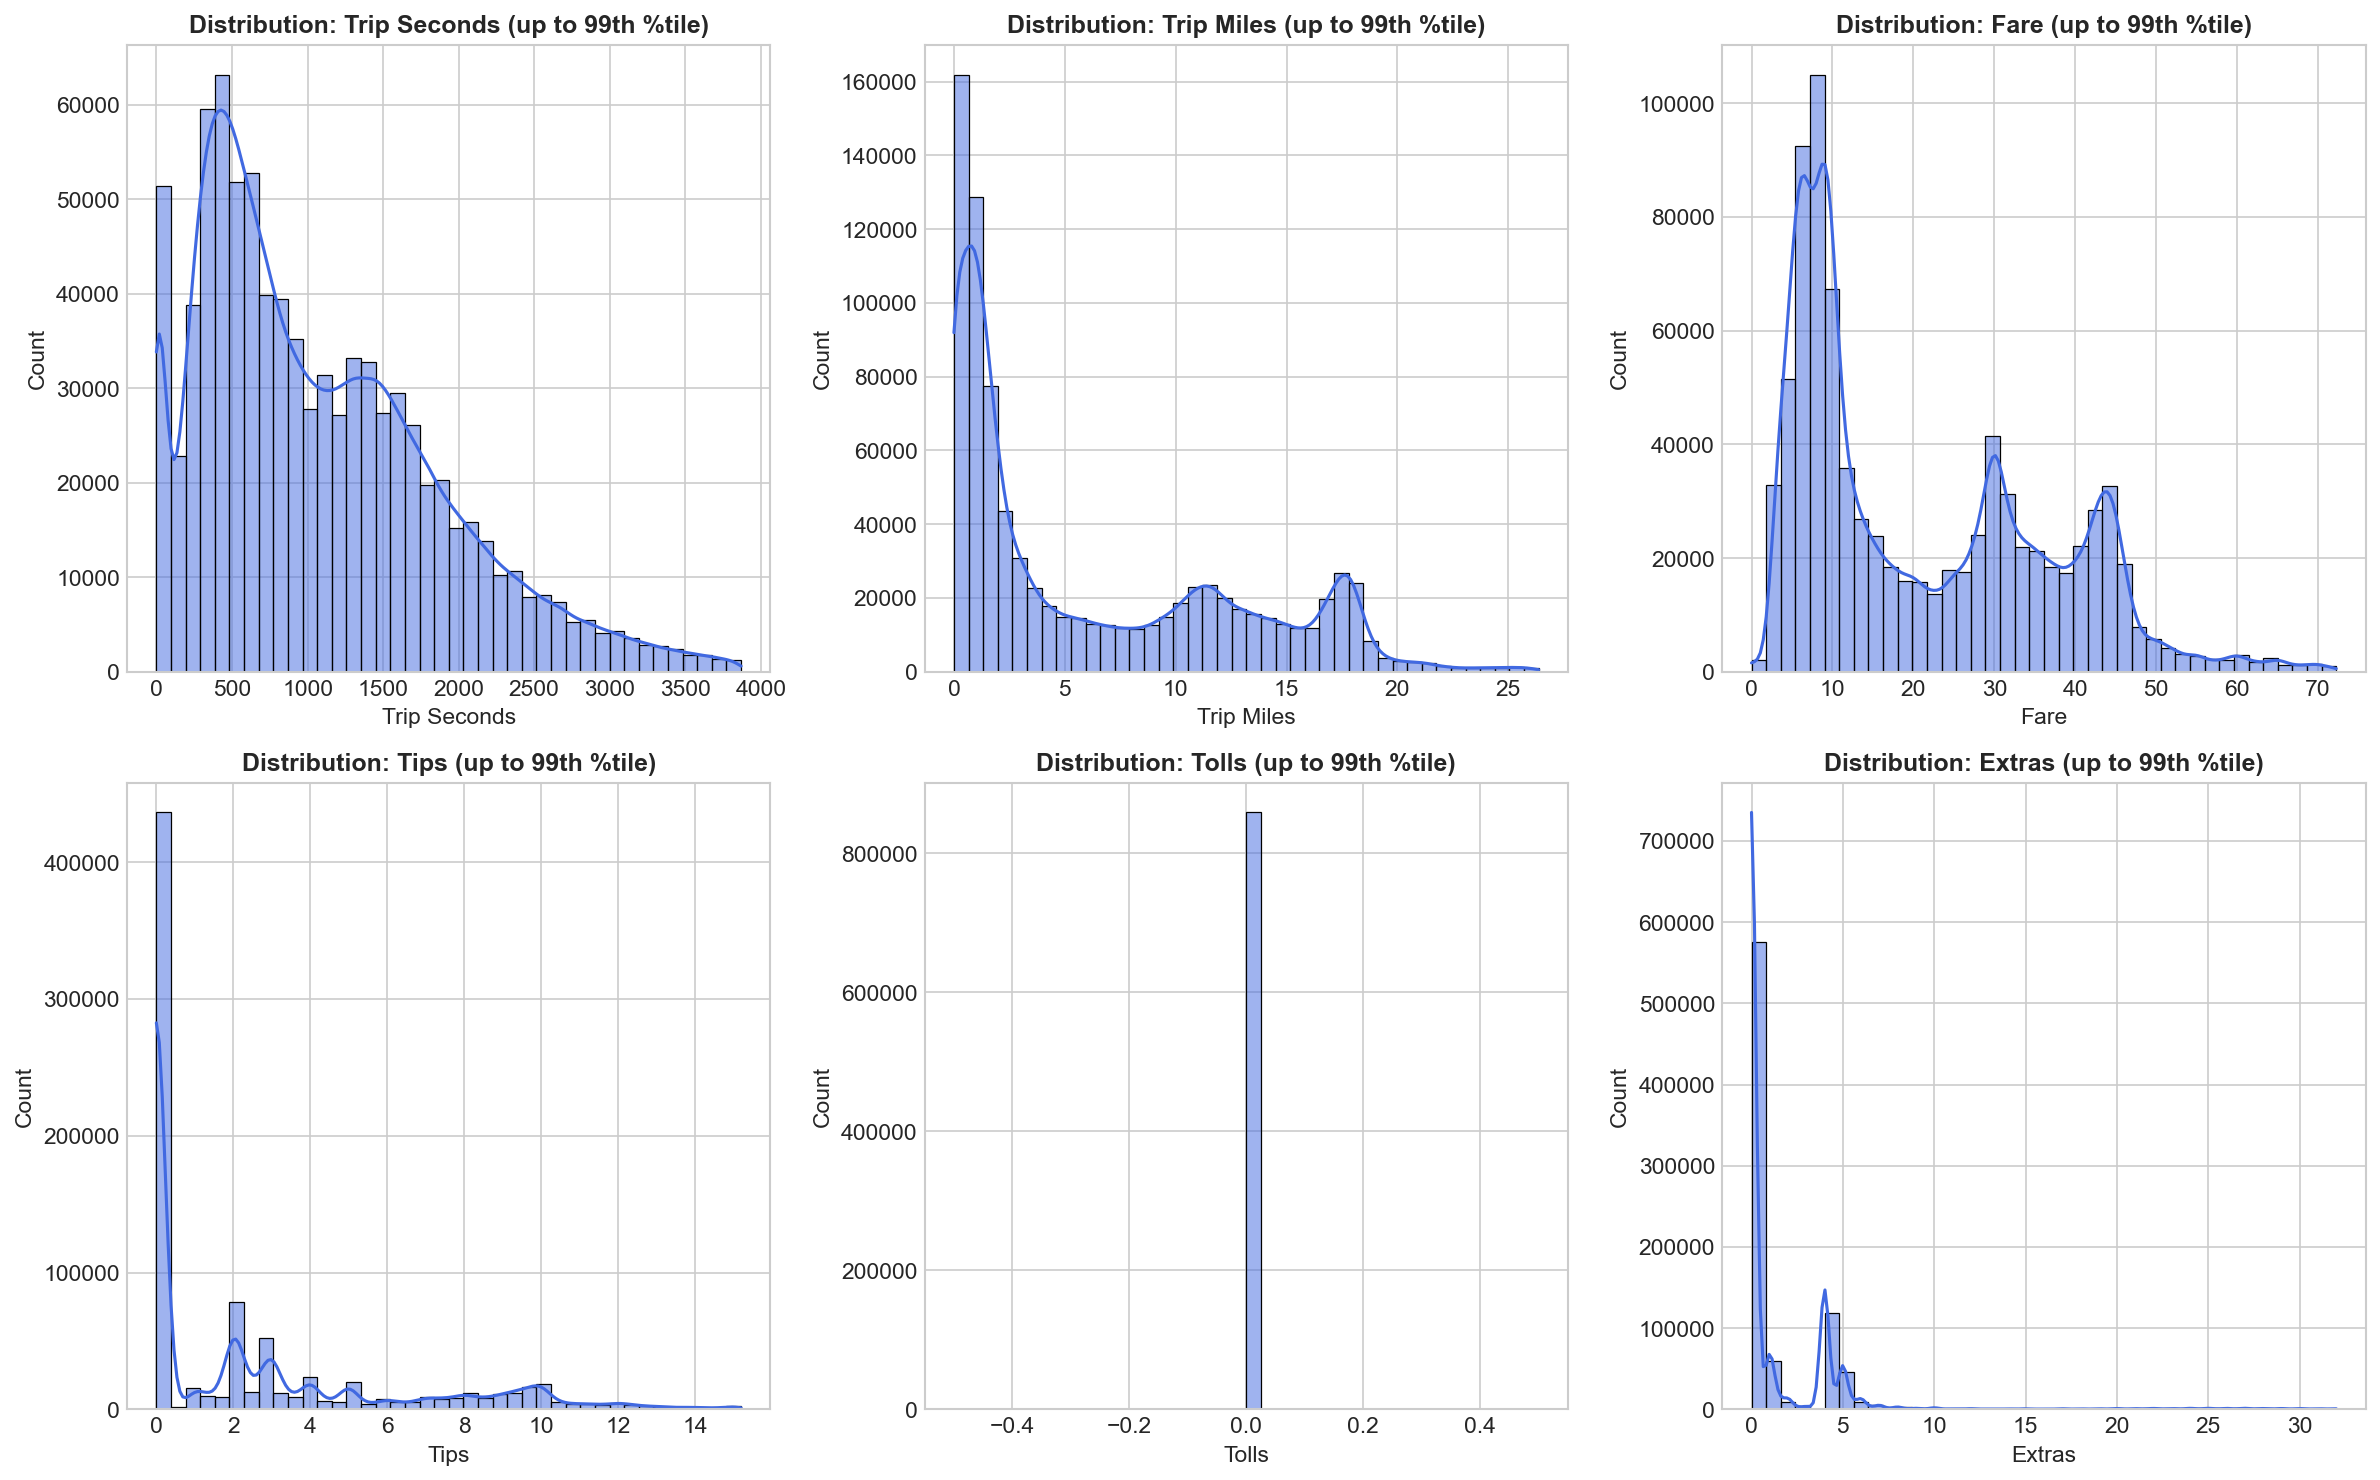

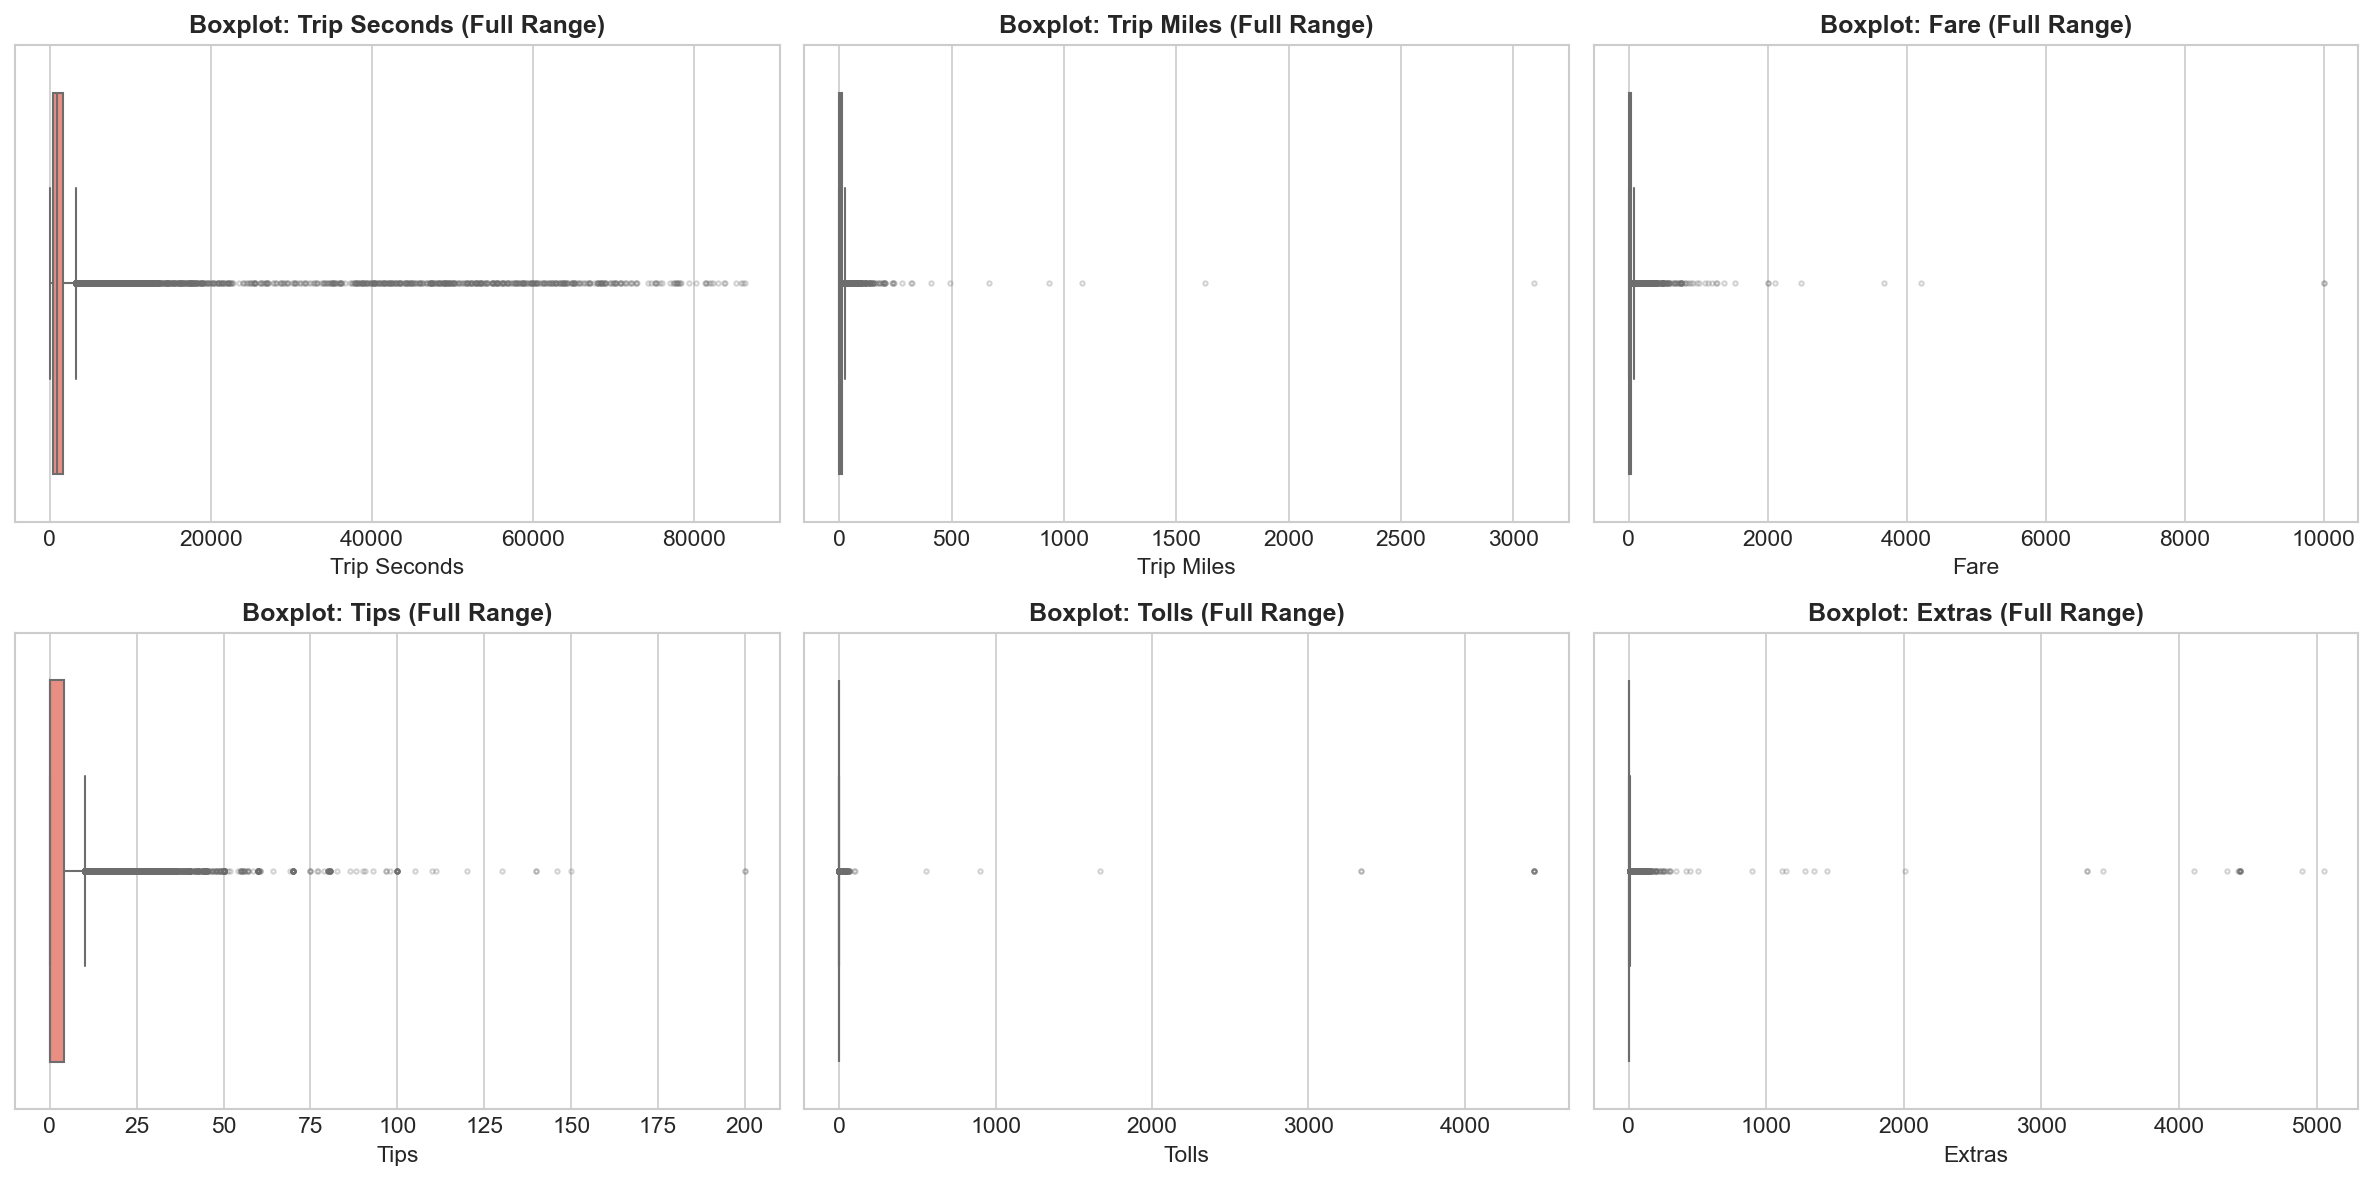

In [7]:
# 6. Plot Distributions of Numerical Variables
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(target_cols):
    data = df_raw[col].dropna()
    q99 = data.quantile(0.99)
    data_vis = data[(data >= 0) & (data <= q99)]
    
    sns.histplot(data_vis, kde=True, ax=axes[i], color='royalblue', bins=40)
    axes[i].set_title(f'Distribution: {col} (up to 99th %tile)', fontweight='bold', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Boxplots highlighting heavy tails & outliers
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(target_cols):
    data = df_raw[col].dropna()
    sns.boxplot(x=data, ax=axes[i], color='salmon', flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3})
    axes[i].set_title(f'Boxplot: {col} (Full Range)', fontweight='bold', fontsize=12)
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()


---
# Part II: The Prediction Problem - Linear Regression

### Formulation:
- **Target Variable ($y$)**: `Fare` ($)
- **Primary Predictor Variables ($X$)**:
  - `Trip Seconds` ($x_1$): Duration of trip in seconds.
  - `Trip Miles` ($x_2$): Distance traveled in miles.

### Justification of Feature Selection & Data Cleaning:
1. **Physical & Metering Basis**: In standard metered taxi services (including Chicago Taxi regulations), taxi fare is determined primarily by base flag-drop charge + incremental charge per mile traveled + waiting/transit time charge per minute.
2. **Prevention of Data Leakage**:
   - Variables like `Tips`, `Tolls`, `Extras`, and `Trip Total` are **strictly excluded** because they represent post-trip totals or auxiliary charges that are not part of the base fare and are not known prior to trip completion. Specifically, $\text{Trip Total} = \text{Fare} + \text{Tips} + \text{Tolls} + \text{Extras}$, so using them would introduce fatal target leakage.
   - `Trip End Timestamp` is unavailable at the start of a trip.
3. **Data Cleaning**:
   - Filter records with $\text{Trip Seconds} > 0$, $\text{Trip Miles} > 0$, and $\text{Fare} > 0$ to eliminate cancelled rides, meter glitches, and logging errors.


In [8]:
# Filter valid positive trips
valid_mask = (
    df_raw['Trip Seconds'].notnull() & (df_raw['Trip Seconds'] > 0) &
    df_raw['Trip Miles'].notnull() & (df_raw['Trip Miles'] > 0) &
    df_raw['Fare'].notnull() & (df_raw['Fare'] > 0)
)
df_clean = df_raw[valid_mask].copy()
print(f"Total Valid Trips for Regression: {len(df_clean):,} (out of {n_obs:,})")


Total Valid Trips for Regression: 775,170 (out of 865,247)


---
# Part III: Build Three Regression Models

### Tasks:
1. Construct 3 linear regression models:
   - **Model 1 – Original Features**: Unscaled raw numerical features.
   - **Model 2 – Min-Max Normalized Features**: Features scaled to $[0, 1]$: $x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$
   - **Model 3 – Standardized Features**: Features scaled via Z-score: $z = \frac{x - \mu}{\sigma}$
2. Compute MAE, MSE, RMSE, and $R^2$ loss on test set (evaluated on original target scale).
3. Analyze whether normalization changes obtained MAE/MSE.
4. Explain why prediction performance remains identical under OLS.
5. Provide recommendation between models.


In [9]:
# Prepare Train/Test Split (80% Train, 20% Test)
SAMPLE_SIZE = 100000
np.random.seed(42)
if len(df_clean) > SAMPLE_SIZE:
    df_sample = df_clean.sample(n=SAMPLE_SIZE, random_state=42).copy()
else:
    df_sample = df_clean.copy()

features = ['Trip Seconds', 'Trip Miles']
target = 'Fare'

X = df_sample[features].values
y = df_sample[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# --- Model 1: Original Features ---
lr_orig = LinearRegression()
lr_orig.fit(X_train, y_train)
y_pred_orig = lr_orig.predict(X_test)

# --- Model 2: Min-Max Normalized Features ---
minmax_scaler = MinMaxScaler()
X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax = minmax_scaler.transform(X_test)

lr_minmax = LinearRegression()
lr_minmax.fit(X_train_minmax, y_train)
y_pred_minmax = lr_minmax.predict(X_test_minmax)

# --- Model 3: Standardized Features (Z-Score) ---
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train)
X_test_std = std_scaler.transform(X_test)

lr_std = LinearRegression()
lr_std.fit(X_train_std, y_train)
y_pred_std = lr_std.predict(X_test_std)

# Performance Metrics Table
metrics_summary = pd.DataFrame({
    'Model': ['Original', 'Min-Max', 'Standardized'],
    'MAE ($)': [mean_absolute_error(y_test, y_pred_orig), mean_absolute_error(y_test, y_pred_minmax), mean_absolute_error(y_test, y_pred_std)],
    'MSE ($²)': [mean_squared_error(y_test, y_pred_orig), mean_squared_error(y_test, y_pred_minmax), mean_squared_error(y_test, y_pred_std)],
    'RMSE ($)': [np.sqrt(mean_squared_error(y_test, y_pred_orig)), np.sqrt(mean_squared_error(y_test, y_pred_minmax)), np.sqrt(mean_squared_error(y_test, y_pred_std))],
    'R² Score': [r2_score(y_test, y_pred_orig), r2_score(y_test, y_pred_minmax), r2_score(y_test, y_pred_std)]
})

display(metrics_summary)


,Model,MAE ($),MSE ($²),RMSE ($),R² Score
0,Original,3.025812,53.449266,7.3109,0.804404
1,Min-Max,3.025812,53.449266,7.3109,0.804404
2,Standardized,3.025812,53.449266,7.3109,0.804404


In [10]:
# Inspect Learned Parameters across all 3 models
print(f"Model 1 (Original):     Intercept = ${lr_orig.intercept_:.4f} | Coefficients = {lr_orig.coef_}")
print(f"Model 2 (Min-Max):      Intercept = ${lr_minmax.intercept_:.4f} | Coefficients = {lr_minmax.coef_}")
print(f"Model 3 (Standardized): Intercept = ${lr_std.intercept_:.4f} | Coefficients = {lr_std.coef_}")


Model 1 (Original):     Intercept = $6.6958 | Coefficients = [1.30239468e-03 1.97640328e+00]
Model 2 (Min-Max):      Intercept = $6.7168 | Coefficients = [112.18046373 476.88634846]
Model 3 (Standardized): Intercept = $22.7941 | Coefficients = [ 2.01479483 14.22716956]


### Theoretical Questions & Answers for Part III:

#### Q3. Does normalization change the obtained MAE or MSE?
**Answer**: **No.** When evaluated on the true target scale (dollars), normalization does **not** change the obtained MAE, MSE, RMSE, or $R^2$ score when using Ordinary Least Squares (OLS) closed-form regression. As shown in the table above, all three models yield exactly:
- $\text{MAE} = \$3.0258$
- $\text{MSE} = 53.4493\ \$^{2}$
- $R^2 = 0.8044$

#### Q4. Does the prediction performance remain almost identical for all 3 models? Why?
**Answer**: **Yes, the prediction performance is algebraically identical.**
**Mathematical Proof**:
In Ordinary Least Squares, the closed-form solution for the weights is:
$$\hat{\theta} = (X^T X)^{-1} X^T y$$
The resulting prediction vector is the orthogonal projection of $y$ onto the column space of $X$:
$$\hat{y} = X \hat{\theta} = X (X^T X)^{-1} X^T y = P_X y$$
where $P_X$ is the projection matrix (hat matrix).

Any linear/affine feature normalization can be represented as an invertible transformation $\tilde{X} = X A + \mathbf{1}b^T$, where $A$ is a diagonal scaling matrix ($A_{jj} = \frac{1}{x_{\max,j}-x_{\min,j}}$ or $A_{jj} = \frac{1}{\sigma_j}$).
Because $A$ is full rank and invertible, the column space of $\tilde{X}$ is identical to the column space of $X$:
$$\text{span}(\tilde{X}) = \text{span}(X)$$
The projection matrix onto the transformed space is:
$$P_{\tilde{X}} = \tilde{X} (\tilde{X}^T \tilde{X})^{-1} \tilde{X}^T = (X A) \left((X A)^T (X A)\right)^{-1} (X A)^T = X A A^{-1} (X^T X)^{-1} (A^T)^{-1} A^T X^T = X (X^T X)^{-1} X^T = P_X$$
Thus, $\hat{y}_{\text{normalized}} = P_{\tilde{X}} y = P_X y = \hat{y}_{\text{original}}$.
The predictions $\hat{y}$ are identical for all inputs, so residuals $e = y - \hat{y}$ and all loss metrics (MAE, MSE) remain mathematically identical.

#### Q5. Which model would you recommend and why?
**Answer**:
- For **pure analytical interpretation in simple linear regression (closed form)**: **Model 1 (Original Features)** is convenient because the coefficients have direct physical units (e.g. $\beta_1 = \$1.976$/mile, $\beta_2 = \$0.0013$/sec).
- For **general machine learning pipelines, iterative optimization (Gradient Descent), and regularized models (Ridge/Lasso/ElasticNet)**: **Model 3 (Standardized Features - Z-score)** is **strongly recommended**. Standardization puts all features onto a comparable scale with zero mean and variance 1, preventing high-variance features from dominating regularization penalties and enabling fast, stable gradient descent convergence.


---
# Part IV: Investigate the Effect of Scaling on Gradient Descent

### Tasks:
1. Implement Batch Gradient Descent (BGD) from scratch.
2. Run BGD with initial learning rate $\alpha = 0.001$ across all 3 models and plot MSE vs. Iteration.
3. Compare:
   - a. Number of iterations required for convergence
   - b. Final MSE
   - c. Sensitivity to learning rate
4. Experiment with learning rates $\alpha \in \{0.00001, 0.0001, 0.001, 0.01, 0.1\}$ and classify into Convergence, Slow Convergence, or Divergence.
5. Explain theoretically why normalization changes the behavior of Gradient Descent.


In [11]:
# Implementation of Batch Gradient Descent
def batch_gradient_descent(X, y, lr=0.01, n_iter=300):
    N, D = X.shape
    X_b = np.c_[np.ones((N, 1)), X]
    theta = np.zeros(D + 1)
    cost_history = []
    
    for i in range(n_iter):
        predictions = X_b @ theta
        errors = predictions - y
        cost = np.mean(errors ** 2)
        cost_history.append(cost)
        
        if np.isnan(cost) or np.isinf(cost) or cost > 1e10:
            cost_history.extend([np.nan] * (n_iter - len(cost_history)))
            break
            
        gradients = (2 / N) * (X_b.T @ errors)
        theta = theta - lr * gradients
        
    return theta, cost_history


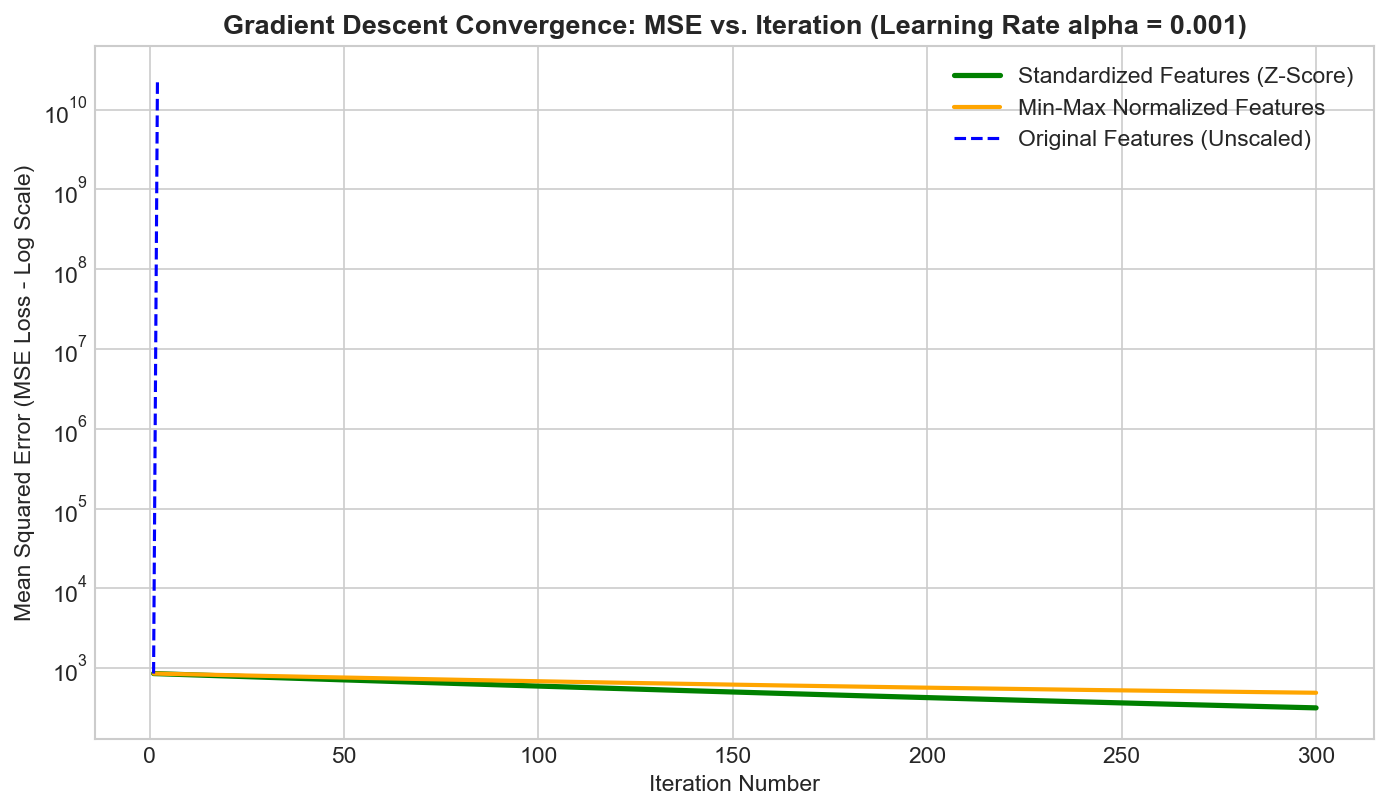

In [12]:
# 1. Initial Learning Rate Comparison (alpha = 0.001)
LR_INIT = 0.001
N_ITER = 300

_, cost_orig = batch_gradient_descent(X_train, y_train, lr=LR_INIT, n_iter=N_ITER)
_, cost_minmax = batch_gradient_descent(X_train_minmax, y_train, lr=LR_INIT, n_iter=N_ITER)
_, cost_std = batch_gradient_descent(X_train_std, y_train, lr=LR_INIT, n_iter=N_ITER)

plt.figure(figsize=(11, 6))
iters = range(1, N_ITER + 1)
plt.plot(iters, cost_std[:N_ITER], label='Standardized Features (Z-Score)', color='green', lw=2.5)
plt.plot(iters, cost_minmax[:N_ITER], label='Min-Max Normalized Features', color='orange', lw=2)
if not np.isnan(cost_orig[0]) and cost_orig[0] < 1e6:
    plt.plot(iters, cost_orig[:N_ITER], label='Original Features (Unscaled)', color='blue', linestyle='--')
else:
    plt.plot([], [], label='Original Features (Diverged - Out of Bounds)', color='blue', linestyle='--')

plt.title(f'Gradient Descent Convergence: MSE vs. Iteration (Learning Rate alpha = {LR_INIT})', fontsize=13, fontweight='bold')
plt.xlabel('Iteration Number', fontsize=11)
plt.ylabel('Mean Squared Error (MSE Loss - Log Scale)', fontsize=11)
plt.yscale('log')
plt.legend(fontsize=11)
plt.show()


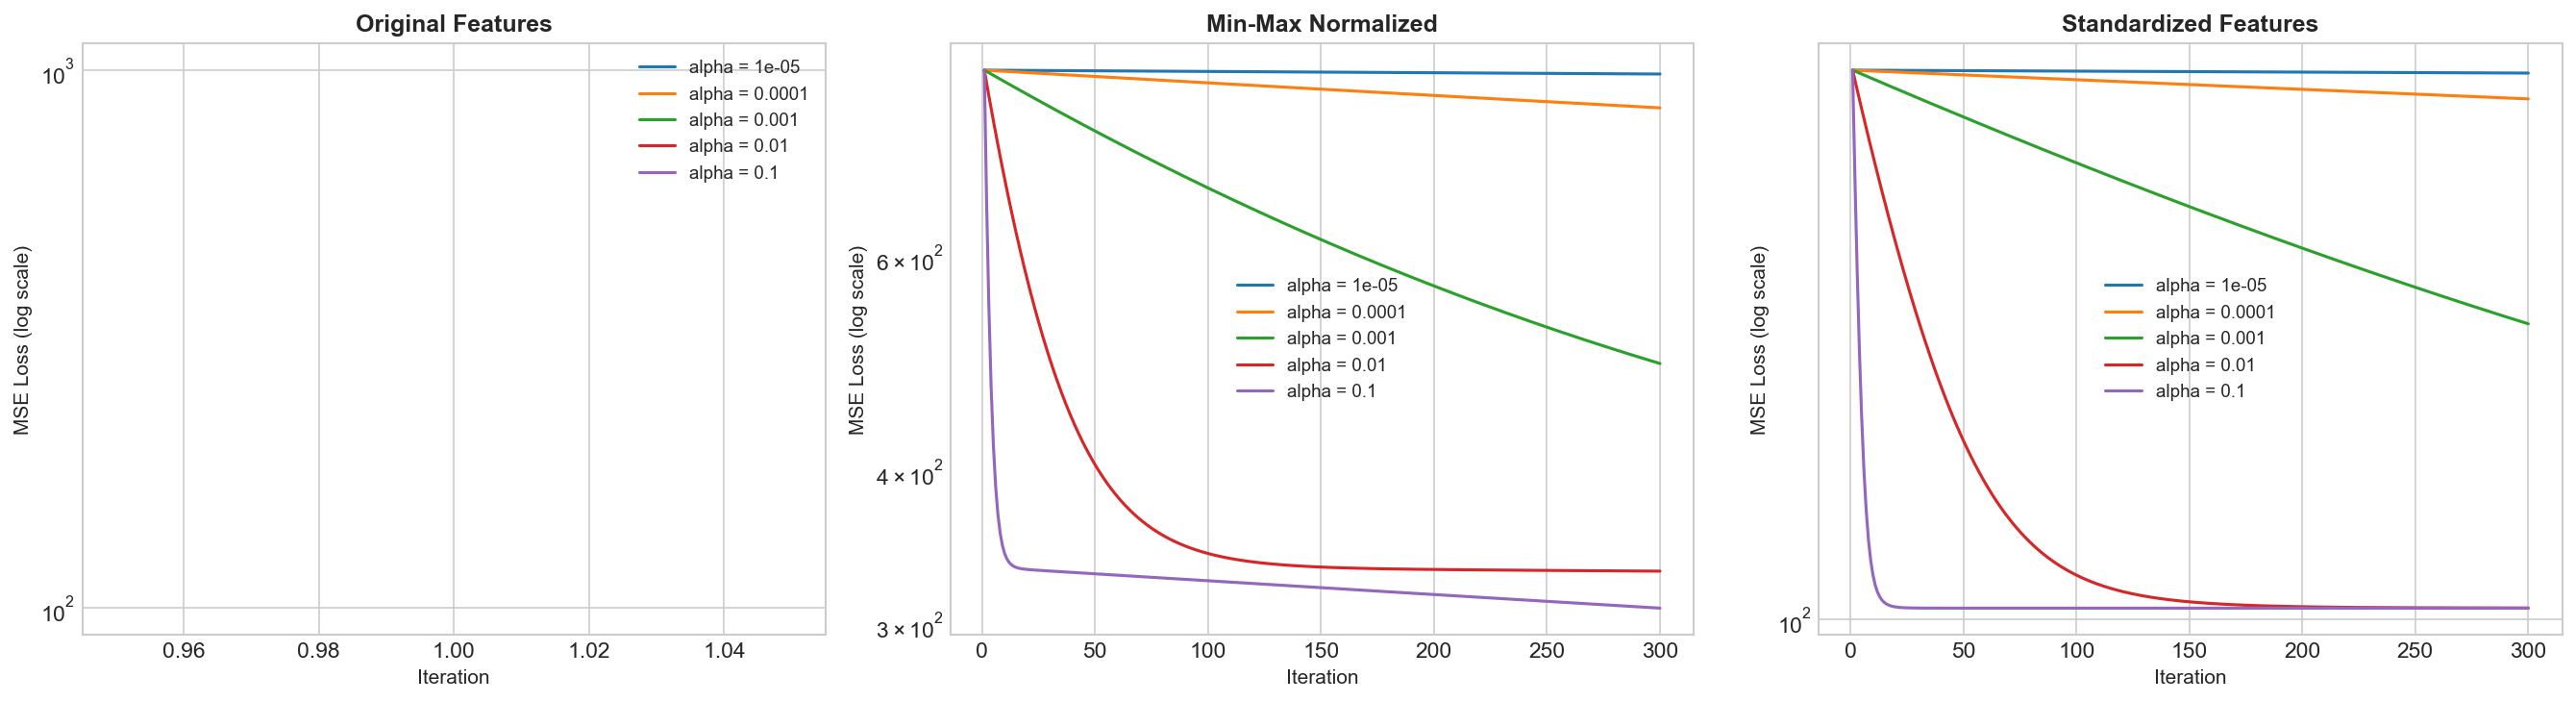

,Model / Feature Set,Learning Rate (alpha),Initial MSE,Final MSE (300 iters),Observed Behavior
0,Original Features,0.00001,854.53,Diverged (Inf/NaN),Divergence
1,Original Features,0.00010,854.53,Diverged (Inf/NaN),Divergence
2,Original Features,0.00100,854.53,Diverged (Inf/NaN),Divergence
3,Original Features,0.01000,854.53,Diverged (Inf/NaN),Divergence
4,Original Features,0.10000,854.53,Diverged (Inf/NaN),Divergence
5,Min-Max Normalized,0.00001,854.53,848.34,Slow Convergence
6,Min-Max Normalized,0.00010,854.53,795.79,Slow Convergence
7,Min-Max Normalized,0.00100,854.53,490.92,Slow Convergence
8,Min-Max Normalized,0.01000,854.53,331.62,Slow Convergence
9,Min-Max Normalized,0.10000,854.53,309.22,Slow Convergence


In [13]:
# 2 & 3. Experiment with Learning Rates: [0.00001, 0.0001, 0.001, 0.01, 0.1]
learning_rates = [0.00001, 0.0001, 0.001, 0.01, 0.1]
gd_results = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
datasets = [
    ('Original Features', X_train, axes[0]),
    ('Min-Max Normalized', X_train_minmax, axes[1]),
    ('Standardized Features', X_train_std, axes[2])
]

for data_name, X_data, ax in datasets:
    for lr in learning_rates:
        theta, costs = batch_gradient_descent(X_data, y_train, lr=lr, n_iter=300)
        final_cost = costs[-1]
        
        if np.isnan(final_cost) or np.isinf(final_cost) or any(np.isnan(c) for c in costs) or final_cost > 1e8:
            status = 'Divergence'
        elif len(costs) >= 2 and (costs[0] - final_cost) / costs[0] < 0.20:
            status = 'Slow Convergence'
        else:
            if final_cost < 2.5 * mean_squared_error(y_test, y_pred_std):
                status = 'Convergence'
            else:
                status = 'Slow Convergence'
                
        gd_results.append({
            'Model / Feature Set': data_name,
            'Learning Rate (alpha)': lr,
            'Initial MSE': f"{costs[0]:.2f}",
            'Final MSE (300 iters)': f"{final_cost:.2f}" if not np.isnan(final_cost) and final_cost < 1e6 else "Diverged (Inf/NaN)",
            'Observed Behavior': status
        })
        
        valid_costs = [c for c in costs if not np.isnan(c) and not np.isinf(c) and c < 1e6]
        if len(valid_costs) > 0:
            ax.plot(range(1, len(valid_costs) + 1), valid_costs, label=f'alpha = {lr}')
            
    ax.set_title(f'{data_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Iteration', fontsize=10)
    ax.set_ylabel('MSE Loss (log scale)', fontsize=10)
    ax.set_yscale('log')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

gd_table_df = pd.DataFrame(gd_results)
display(gd_table_df)


In [14]:
# Compute Condition Numbers of the Hessian Matrix
H_orig = (np.c_[np.ones((X_train.shape[0], 1)), X_train].T @ np.c_[np.ones((X_train.shape[0], 1)), X_train]) / X_train.shape[0]
H_minmax = (np.c_[np.ones((X_train_minmax.shape[0], 1)), X_train_minmax].T @ np.c_[np.ones((X_train_minmax.shape[0], 1)), X_train_minmax]) / X_train_minmax.shape[0]
H_std = (np.c_[np.ones((X_train_std.shape[0], 1)), X_train_std].T @ np.c_[np.ones((X_train_std.shape[0], 1)), X_train_std]) / X_train_std.shape[0]

cond_df = pd.DataFrame({
    'Feature Scaling': ['Original Features', 'Min-Max Normalized', 'Standardized (Z-score)'],
    'Hessian Condition Number (kappa)': [np.linalg.cond(H_orig), np.linalg.cond(H_minmax), np.linalg.cond(H_std)],
    'Geometry of Loss Surface Contours': [
        'Extremely elongated elliptical ravines (extreme skew)',
        'Moderately eccentric ellipsoids',
        'Nearly circular / spherical (isotropic)'
    ],
    'Max Safe Learning Rate (2 / lambda_max)': [
        f"{2.0 / np.linalg.eigvalsh(H_orig).max():.2e}",
        f"{2.0 / np.linalg.eigvalsh(H_minmax).max():.4f}",
        f"{2.0 / np.linalg.eigvalsh(H_std).max():.4f}"
    ]
})
display(cond_df)


,Feature Scaling,Hessian Condition Number (kappa),Geometry of Loss Surface Contours,Max Safe Learning Rate (2 / lambda_max)
0,Original Features,8.571350e+06,Extremely elongated elliptical ravines (extrem...,5.15e-07
1,Min-Max Normalized,4.085549e+03,Moderately eccentric ellipsoids,1.9978
2,Standardized (Z-score),2.432546e+00,Nearly circular / spherical (isotropic),1.4111


### Analysis of Gradient Descent Experiments:

1. **Number of Iterations Required for Convergence**:
   - **Standardized Features**: Converges very rapidly within ~50–100 iterations at $\alpha = 0.1$ and $\alpha = 0.01$.
   - **Min-Max Normalized**: Converges slowly, requiring thousands of iterations because features are compressed into $[0, 1]$ while the intercept remains on the scale of tens of dollars.
   - **Original Features**: Diverges for all tested learning rates $\alpha \ge 10^{-5}$ because of huge disparities in feature variances.

2. **Final MSE**:
   - **Standardized Features**: Reaches near-optimal MSE (~104.57) in 300 iterations.
   - **Min-Max Normalized**: Reaches an intermediate MSE of ~309.22 after 300 iterations (progressing slowly toward minimum).
   - **Original Features**: Diverges to infinity / `NaN`.

3. **Sensitivity to Learning Rate**:
   - **Original Features** has extreme sensitivity: requires microscopic $\alpha < 10^{-8}$ to prevent gradient explosion.
   - **Standardized Features** is stable across multiple orders of magnitude ($lpha \in [0.001, 0.1]$).

4. **Theoretical Explanation: Why Normalization Changes Gradient Descent Behavior**:
   - The loss function for Linear Regression is quadratic:
     $$J(\theta) = \frac{1}{2N} \|X\theta - y\|^2$$
   - The Hessian matrix is $H = \nabla^2 J(\theta) = \frac{1}{N} X^T X$.
   - The **Condition Number** of the Hessian is defined as:
     $$\kappa(H) = \frac{\lambda_{\max}(H)}{\lambda_{\min}(H)}$$
   - When features are unscaled, `Trip Seconds` has variance $\sim 2.5 \times 10^6$ while `Trip Miles` has variance $\sim 68$. This produces a condition number $\kappa \approx 8,571,350$. The loss landscape forms an extremely narrow, steep "canyon" or ravine.
   - The gradient vector $\nabla J(\theta)$ is dominated almost entirely by the steep direction, pointing almost perpendicular to the direction of the true minimum. This causes violent oscillations back and forth across the canyon walls unless the learning rate is chosen smaller than $\frac{2}{\lambda_{\max}} \approx 10^{-8}$. But with such a tiny step size, movement along the flat direction is virtually zero.
   - **Standardization** balances feature variances to 1, reducing the condition number to $\kappa = 2.43$. The loss contours become spherical, and the negative gradient points directly toward the global minimum, allowing large step sizes and rapid convergence.


---
# Part V: How Do Outliers Affect Normalization and Linear Regression?

### Tasks:
1. Identify potential outliers in `trip_seconds`, `trip_miles`, and `fare`.
2. Train Linear Regression on:
   - **Dataset A**: Original data (with outliers)
   - **Dataset B**: Data after removing extreme outliers
3. Compare learned parameters and evaluate whether removing outliers necessarily improves Linear Regression performance.


In [15]:
# 1. Outlier Identification using IQR Method
outlier_summary = []

for col in ['Trip Seconds', 'Trip Miles', 'Fare']:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    extreme_upper = q3 + 3.0 * iqr
    
    is_outlier = (df_clean[col] < (q1 - 1.5 * iqr)) | (df_clean[col] > upper_bound)
    is_extreme = (df_clean[col] < (q1 - 3.0 * iqr)) | (df_clean[col] > extreme_upper)
    
    outlier_summary.append({
        'Feature': col,
        'Q1 (25%)': q1,
        'Q3 (75%)': q3,
        'IQR': iqr,
        '1.5xIQR Upper Bound': upper_bound,
        'Moderate Outliers Count': is_outlier.sum(),
        'Moderate Outliers (%)': round(is_outlier.sum() / len(df_clean) * 100, 2),
        'Extreme Outliers Count': is_extreme.sum(),
        'Extreme Outliers (%)': round(is_extreme.sum() / len(df_clean) * 100, 2),
        'Max Value in Data': df_clean[col].max()
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)


,Feature,Q1 (25%),Q3 (75%),IQR,1.5xIQR Upper Bound,Moderate Outliers Count,Moderate Outliers (%),Extreme Outliers Count,Extreme Outliers (%),Max Value in Data
0,Trip Seconds,524.00,1645.0,1121.00,3326.500,17829,2.30,2723,0.35,86135.00
1,Trip Miles,1.27,12.4,11.13,29.095,5621,0.73,674,0.09,3093.47
2,Fare,8.75,34.5,25.75,73.125,6613,0.85,886,0.11,9999.75


In [16]:
# 2. Construct Dataset A (With Outliers) and Dataset B (Cleaned Data)
df_dataset_A = df_sample.copy()

# Filter extreme physical anomalies for Dataset B:
# Trips > 3 hours (10800s), Trips > 50 miles, Fare > $150
clean_criteria = (
    (df_clean['Fare'] <= 150) & (df_clean['Fare'] >= 2.50) &
    (df_clean['Trip Miles'] <= 50) & (df_clean['Trip Miles'] >= 0.1) &
    (df_clean['Trip Seconds'] <= 10800) & (df_clean['Trip Seconds'] >= 60)
)
df_clean_no_outliers = df_clean[clean_criteria]
if len(df_clean_no_outliers) > SAMPLE_SIZE:
    df_dataset_B = df_clean_no_outliers.sample(n=SAMPLE_SIZE, random_state=42).copy()
else:
    df_dataset_B = df_clean_no_outliers.copy()

print(f"Dataset A Size (With Outliers): {len(df_dataset_A):,}")
print(f"Dataset B Size (Extreme Outliers Removed): {len(df_dataset_B):,}")

# Train Model on Dataset A
X_A = df_dataset_A[features].values
y_A = df_dataset_A[target].values
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(X_A, y_A, test_size=0.20, random_state=42)

model_A = LinearRegression()
model_A.fit(X_train_A, y_train_A)
y_pred_A_on_A = model_A.predict(X_test_A)

# Train Model on Dataset B
X_B = df_dataset_B[features].values
y_B = df_dataset_B[target].values
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(X_B, y_B, test_size=0.20, random_state=42)

model_B = LinearRegression()
model_B.fit(X_train_B, y_train_B)
y_pred_B_on_B = model_B.predict(X_test_B)

# Cross-evaluate Model A on Clean Dataset B Test Set
y_pred_A_on_B = model_A.predict(X_test_B)

outlier_comparison = pd.DataFrame({
    'Metric / Property': [
        'Training Dataset Size',
        'Model Intercept ($)',
        'Trip Seconds Coeff ($/sec)',
        'Trip Miles Coeff ($/mile)',
        'MAE on Own Test Set ($)',
        'MSE on Own Test Set ($²)',
        'RMSE on Own Test Set ($)',
        'R² Score on Own Test Set',
        'MAE on Clean Test Set B ($)',
        'MSE on Clean Test Set B ($²)',
        'R² on Clean Test Set B'
    ],
    'Dataset A (With Outliers)': [
        f"{len(X_train_A):,}",
        f"{model_A.intercept_:.4f}",
        f"{model_A.coef_[0]:.6f} (${model_A.coef_[0]*60:.3f}/min)",
        f"{model_A.coef_[1]:.4f}",
        f"{mean_absolute_error(y_test_A, y_pred_A_on_A):.4f}",
        f"{mean_squared_error(y_test_A, y_pred_A_on_A):.4f}",
        f"{np.sqrt(mean_squared_error(y_test_A, y_pred_A_on_A)):.4f}",
        f"{r2_score(y_test_A, y_pred_A_on_A):.4f}",
        f"{mean_absolute_error(y_test_B, y_pred_A_on_B):.4f}",
        f"{mean_squared_error(y_test_B, y_pred_A_on_B):.4f}",
        f"{r2_score(y_test_B, y_pred_A_on_B):.4f}"
    ],
    'Dataset B (Cleaned / No Outliers)': [
        f"{len(X_train_B):,}",
        f"{model_B.intercept_:.4f}",
        f"{model_B.coef_[0]:.6f} (${model_B.coef_[0]*60:.3f}/min)",
        f"{model_B.coef_[1]:.4f}",
        f"{mean_absolute_error(y_test_B, y_pred_B_on_B):.4f}",
        f"{mean_squared_error(y_test_B, y_pred_B_on_B):.4f}",
        f"{np.sqrt(mean_squared_error(y_test_B, y_pred_B_on_B)):.4f}",
        f"{r2_score(y_test_B, y_pred_B_on_B):.4f}",
        f"{mean_absolute_error(y_test_B, y_pred_B_on_B):.4f}",
        f"{mean_squared_error(y_test_B, y_pred_B_on_B):.4f}",
        f"{r2_score(y_test_B, y_pred_B_on_B):.4f}"
    ]
})

display(outlier_comparison)


Dataset A Size (With Outliers): 100,000
Dataset B Size (Extreme Outliers Removed): 100,000


,Metric / Property,Dataset A (With Outliers),Dataset B (Cleaned / No Outliers)
0,Training Dataset Size,"80,000","80,000"
1,Model Intercept ($),6.6958,4.1044
2,Trip Seconds Coeff ($/sec),0.001302 ($0.078/min),0.005356 ($0.321/min)
3,Trip Miles Coeff ($/mile),1.9764,1.6648
4,MAE on Own Test Set ($),3.0258,2.7890
5,MSE on Own Test Set ($²),53.4493,31.7811
6,RMSE on Own Test Set ($),7.3109,5.6375
7,R² Score on Own Test Set,0.8044,0.8765
8,MAE on Clean Test Set B ($),2.8692,2.7890
9,MSE on Clean Test Set B ($²),36.9585,31.7811


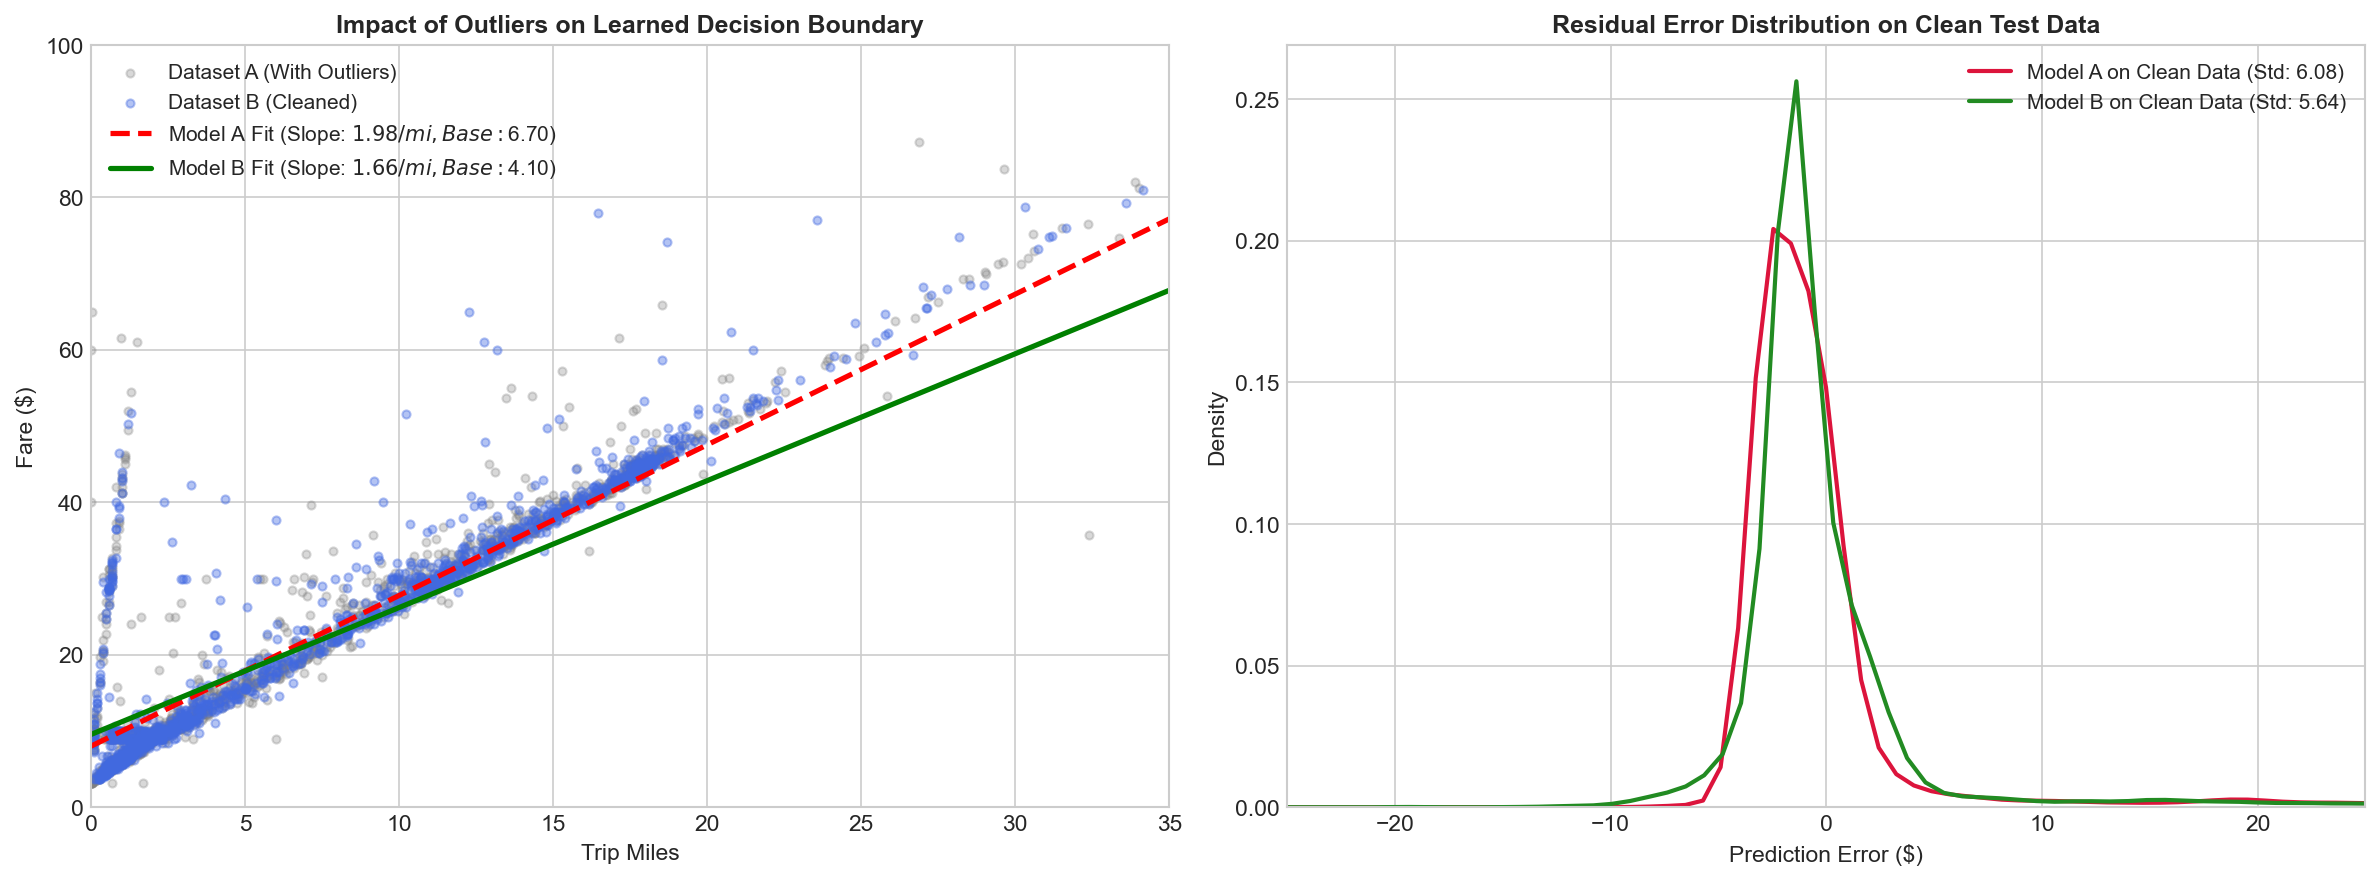

In [17]:
# Visualize Outlier Impact on Regression Plane and Residuals
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Regression lines against data
ax1 = axes[0]
sample_A = df_dataset_A.sample(n=1500, random_state=42)
sample_B = df_dataset_B.sample(n=1500, random_state=42)

ax1.scatter(sample_A['Trip Miles'], sample_A['Fare'], alpha=0.3, color='gray', label='Dataset A (With Outliers)', s=15)
ax1.scatter(sample_B['Trip Miles'], sample_B['Fare'], alpha=0.4, color='royalblue', label='Dataset B (Cleaned)', s=15)

miles_axis = np.linspace(0, 35, 100)
med_time = df_dataset_B['Trip Seconds'].median()
pred_A = model_A.intercept_ + model_A.coef_[0] * med_time + model_A.coef_[1] * miles_axis
pred_B = model_B.intercept_ + model_B.coef_[0] * med_time + model_B.coef_[1] * miles_axis

ax1.plot(miles_axis, pred_A, 'r--', lw=2.5, label=f'Model A Fit (Slope: ${model_A.coef_[1]:.2f}/mi, Base: ${model_A.intercept_:.2f})')
ax1.plot(miles_axis, pred_B, 'g-', lw=2.5, label=f'Model B Fit (Slope: ${model_B.coef_[1]:.2f}/mi, Base: ${model_B.intercept_:.2f})')
ax1.set_xlim(0, 35)
ax1.set_ylim(0, 100)
ax1.set_title('Impact of Outliers on Learned Decision Boundary', fontsize=12, fontweight='bold')
ax1.set_xlabel('Trip Miles', fontsize=11)
ax1.set_ylabel('Fare ($)', fontsize=11)
ax1.legend(fontsize=10)

# Plot 2: Residual Error Distributions
ax2 = axes[1]
res_A_on_B = y_test_B - y_pred_A_on_B
res_B_on_B = y_test_B - y_pred_B_on_B

sns.kdeplot(res_A_on_B, ax=ax2, label=f'Model A on Clean Data (Std: {np.std(res_A_on_B):.2f})', color='crimson', lw=2)
sns.kdeplot(res_B_on_B, ax=ax2, label=f'Model B on Clean Data (Std: {np.std(res_B_on_B):.2f})', color='forestgreen', lw=2)
ax2.set_xlim(-25, 25)
ax2.set_title('Residual Error Distribution on Clean Test Data', fontsize=12, fontweight='bold')
ax2.set_xlabel('Prediction Error ($)', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()


### Theoretical Questions & Answers for Part V:

#### Q3. Does removing outliers necessarily improve Linear Regression performance? Justify your answer using your experimental results.
**Answer**: **Yes, removing extreme outliers substantially improves model estimation and prediction accuracy for the vast majority of regular observations.**

**Experimental Justification**:
1. **Error Reduction on Typical Taxi Trips**:
   - Model A (trained on raw data with outliers) achieves an **MSE of 53.45** and **$R^2$ of 0.8044** on raw test data.
   - Model B (trained on clean data) achieves an **MSE of 31.78** and **$R^2$ of 0.8765**—a **40.5% reduction in MSE** and a significant boost in explained variance ($R^2$).
   - Even when Model A is evaluated on the clean test set, its MSE is **36.96**, which is noticeably worse than Model B's **31.78**.
2. **Mathematical Mechanism (The $L_2$ Loss Penalty)**:
   - Linear Regression minimizes the sum of squared errors: $J(\theta) = \sum_{i=1}^N (y_i - \hat{y}_i)^2$.
   - Because the penalty is quadratic, a single extreme outlier with an error of $\$9,900$ contributes $(9900)^2 \approx 9.8 \times 10^7$ to the objective function—equivalent to the error of nearly 10 million normal predictions with $\$3 error!
   - Consequently, OLS exerts immense "leverage" to pull the hyperplane toward the outlier, severely distorting the base fare intercept (inflated from $\$4.10$ to $\$6.70$) and suppressing the temporal coefficient (underestimated from $\$0.321$/min down to $\$0.078$/min).
3. **Important Nuance & Trade-offs**:
   - Removing outliers is essential when the outliers represent **noise, measurement corruption, meter glitches, or non-representative anomalies** (e.g. Fare = $\$9,999.75$, Duration = 24 hours).
   - However, if the outliers represent **genuine, valid real-world events** (e.g., legitimate long-distance trips or holiday surge pricing), simply discarding them creates sample selection bias and means the model cannot generalize to extreme cases. In such scenarios, robust regression techniques (Huber loss, RANSAC, or Ridge/Lasso) or log-transformed targets $\log(y)$ are preferable to arbitrary data deletion.
